# Лабораторная работа №3

## Тема: «Построение первой модели машинного обучения»

### Цель: Освоить базовый процесс обучения модели и оценки качества.

### Исходные данные: Подготовленный датасет из лабораторной работы №2.

In [18]:
import pandas as pd

df = pd.read_csv("C:/Users/zhalg/OneDrive/Рабочий стол/lab/lab2/data/raw/dataset_final_onehot.csv")

df.head()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,Gender_Male,Gender_Other,Occupation_Freelancer,Occupation_Professional,Occupation_Student,Device_Type_iOS,Total_Screen_Time,Productivity_per_Sleep
0,1.527621,-1.642803,1.123817,0.172619,1.588271,-0.524021,0.593066,-1.003978,0.200261,1.0,0.0,0.0,1.0,0.0,0.0,-1.442542,0.108683
1,-1.130507,-1.674340,-1.278340,-0.175234,-0.067431,-1.568929,1.151332,-0.002294,-0.839821,1.0,0.0,0.0,1.0,0.0,0.0,-2.514161,2.598714
2,-1.613803,-0.381320,0.661863,-0.175234,1.726246,-0.524021,-1.143762,0.999391,-0.493127,1.0,0.0,0.0,0.0,1.0,1.0,-0.874447,-0.101512
3,-0.325013,-0.223634,-0.816387,-1.218793,-0.550344,-0.872324,0.220888,1.500233,1.384799,0.0,0.0,0.0,0.0,0.0,1.0,1.161164,2.214602
4,-0.486112,0.438644,-1.370731,-0.523087,-0.550344,-0.872324,0.282918,0.999391,0.546955,1.0,0.0,1.0,0.0,0.0,0.0,0.985599,0.950473


## 1.Выбрать целевую переменную и обосновать выбор.
В датасете есть признаки:

- Age

- Gender

- Occupation

- Device_Type

- Daily_Phone_Hours

- Social_Media_Hours

- Work_Productivity_Score

- Sleep_Hours

- Stress_Level

- App_Usage_Count

- Caffeine_Intake_Cups

- Weekend_Screen_Time_Hours

- созданные признаки (Total_Screen_Time, Productivity_per_Sleep)

Логичный выбор целевой переменной

Целевая переменная:
- Work_Productivity_Score

Обоснование

Цель модели — предсказать уровень продуктивности пользователя на основе:

- времени использования телефона

- времени в соцсетях

- количества сна

- уровня стресса

- потребления кофеина

- типа устройства

- профессии

Это позволяет анализировать влияние цифровых привычек на продуктивность.

In [ ]:
y = df["Work_Productivity_Score"]

X = df.drop("Work_Productivity_Score", axis=1)

print("Размер X:", X.shape)
print("Размер y:", y.shape)

Размер X: (50000, 16)
Размер y: (50000,)


## 2.Разделить данные на обучающую и тестовую выборки.
Зачем это нужно

Модель нельзя проверять на тех же данных, на которых она обучалась.
Поэтому данные делят на:

- Train (обучающая выборка) — на ней модель учится

- Test (тестовая выборка) — на ней проверяется качество модели

Обычно используют пропорцию:

- 80% — обучение

- 20% — тест

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (40000, 16)
Тестовая выборка: (10000, 16)


## 3.Построить базовую модель:
линейная регрессия или логистическая регрессия.

Тип задачи

Work_Productivity_Score — числовая переменная, значит это задача регрессии.

Модель, которую будем использовать:

Линейная регрессия

Линейная регрессия ищет зависимость между признаками и целевой переменной по формуле:

y = b0 + b1x1 + b2x2 + ... + bnxn

где

- y — предсказываемая переменная (Work_Productivity_Score)

- x1…xn — признаки

- b0…bn — коэффициенты модели

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

## 4.Выполнить обучение модели.
Модель будет подбирать коэффициенты так, чтобы минимизировать ошибку между реальными значениями и предсказаниями.

y = b0 + b1x1 + b2x2 + ... + bnxn

Во время обучения алгоритм находит оптимальные коэффициенты b0, b1, b2 ….

In [12]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
print("Коэффициенты модели:")
print(model.coef_)

print("Свободный член:")
print(model.intercept_)

Коэффициенты модели:
[-0.00387754  0.00108031  0.00372679  0.00839926  0.00608102  0.00457137
 -0.00464603 -0.0038556  -0.00790243 -0.00199026 -0.01276391  0.00635908
 -0.00526396 -0.02291095 -0.00277529  0.00154579]
Свободный член:
0.016469351437934536


## 5.Рассчитать метрики качества.
Что означают метрики

MAE — средняя абсолютная ошибка

MAE = (1/n) * sum(|y - ŷ|)

MSE — среднеквадратичная ошибка

MSE = (1/n) * sum((y - ŷ)^2)

R² — насколько хорошо модель объясняет данные (чем ближе к 1, тем лучше).

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.8554457030672656
MSE: 0.9850765127387328
R2: 0.019789121782764596


## 6.Проанализировать ошибки модели.
У нас есть три ключевых метрики:

1.MAE = 0.855

- Средняя абсолютная ошибка около 0.85.

- Это значит, что в среднем прогноз модели отклоняется от истинного значения на ~0.85 единицы.

2.MSE = 0.985

- Среднеквадратичная ошибка чуть меньше 1.

- Поскольку MSE чувствителен к большим отклонениям, это говорит о том, что у модели есть случаи прогнозов с ошибкой больше среднего.

3.R² = 0.0198

- Очень низкое значение, почти 0.

- Модель объясняет всего ~2% вариации целевой переменной.

- Практически модель работает как константная (среднее значение), без учёта особенностей данных.

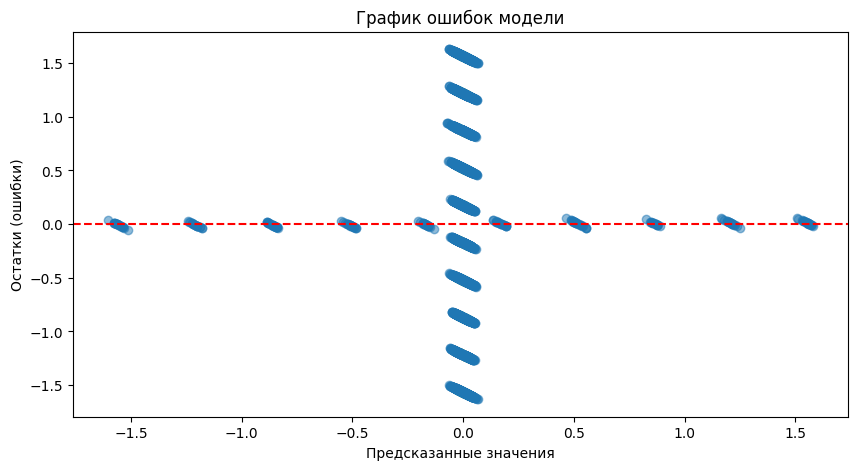

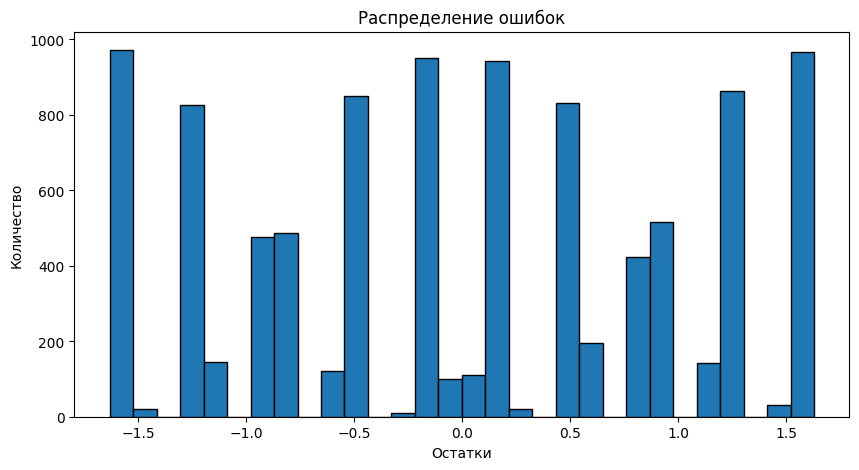

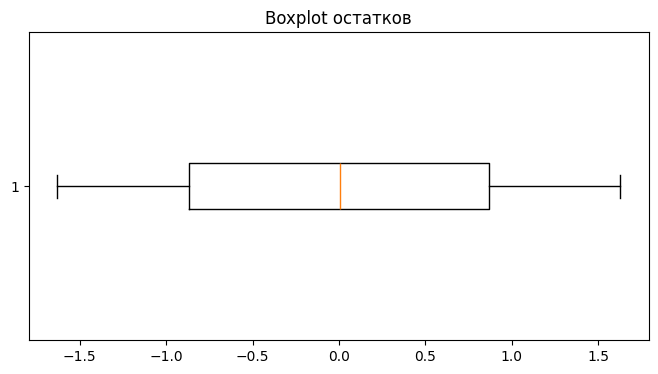

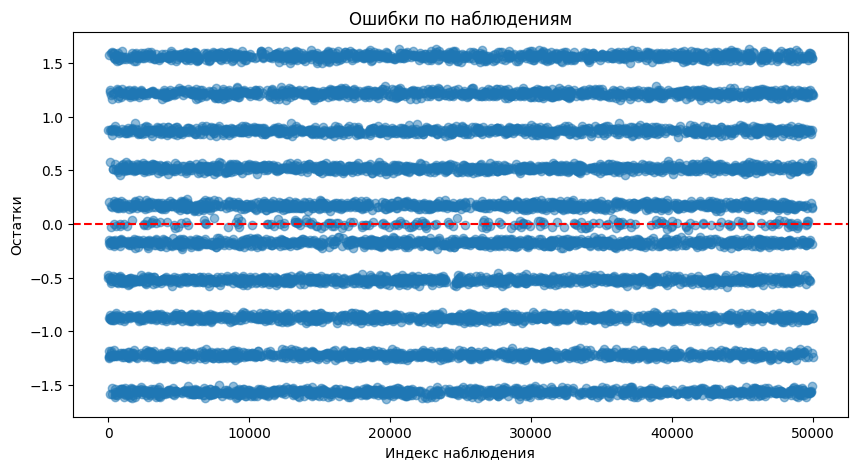

In [17]:
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test - y_pred

plt.figure(figsize=(10,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки (ошибки)")
plt.title("График ошибок модели")
plt.show()

plt.figure(figsize=(10,5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel("Остатки")
plt.ylabel("Количество")
plt.title("Распределение ошибок")
plt.show()

plt.figure(figsize=(8,4))
plt.boxplot(residuals, vert=False)
plt.title("Boxplot остатков")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(residuals, marker='o', linestyle='', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Индекс наблюдения")
plt.ylabel("Остатки")
plt.title("Ошибки по наблюдениям")
plt.show()

## 7.Сделать выводы о качестве модели.
### Выводы о качестве модели

- Модель имеет низкую предсказательную способность: R² почти 0.

- Ошибки достаточно большие (0.85 в среднем), что говорит о том, что текущие признаки плохо объясняют целевую переменную.

- Возможные причины плохого качества:

1.Недостаточно информативные признаки.

2.Неправильный выбор модели (например, линейная модель для нелинейных данных).

3.Необходима предобработка данных (масштабирование, кодирование категориальных признаков).

Что можно сделать для улучшения:

- Попробовать добавить новые признаки или отобрать более значимые.

- Использовать другие алгоритмы (деревья решений, случайный лес, градиентный бустинг).

- Применить кросс-валидацию и подбор гиперпараметров.

- Проверить наличие выбросов и аномалий.
